In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');

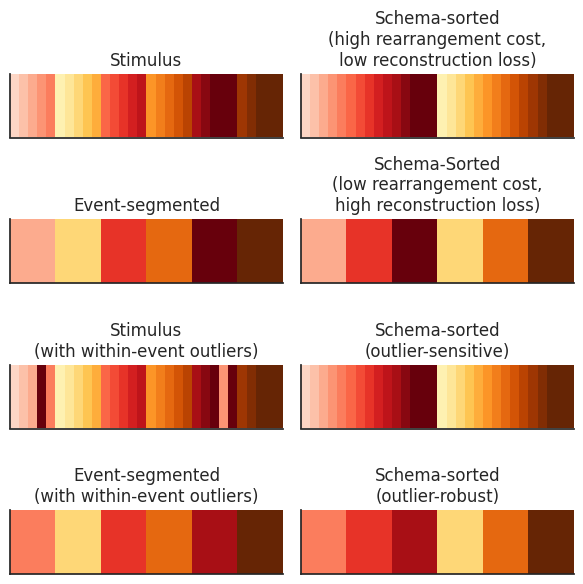

In [2]:
rng = np.random.default_rng(0)
event_templates = [.15, .40, .65, .45, .70, .95]  # initialized in order: reds then yellows
event_templates_swapped = [.65, .40, .15, .95, .70, .45]  # same group, lightest/darkest swapped
narrative_templates = [0, 0, 0, 1, 1, 1]              # 0 = reds, 1 = yellows
n_scenes_per_event, within_event_drift = 5, .1

# schema
schema_noised = np.concatenate([b + np.linspace(-within_event_drift, within_event_drift, n_scenes_per_event) for b in event_templates])
schema_noiseless = np.concatenate([np.full(n_scenes_per_event, b) for b in event_templates])
schema_memberships = np.concatenate([np.full(n_scenes_per_event, nt) for nt in narrative_templates])
# print(f'schema_noised {schema_noised.shape}: {schema_noised}\nschema_noiseless {schema_noiseless.shape}: {schema_noiseless}\nschema_memberships {schema_memberships.shape}: {schema_memberships}\n')

schema_noised_swapped = np.concatenate([b + np.linspace(-within_event_drift, within_event_drift, n_scenes_per_event) for b in event_templates_swapped])

# stimulus
rand_order = [0, 3, 1, 4, 2, 5]
stim = np.concatenate([schema_noised[i*n_scenes_per_event:(i+1)*n_scenes_per_event] for i in rand_order])
stim_noiseless = np.concatenate([schema_noiseless[i*n_scenes_per_event:(i+1)*n_scenes_per_event] for i in rand_order])
stim_memberships = np.concatenate([schema_memberships[i*n_scenes_per_event:(i+1)*n_scenes_per_event] for i in rand_order])
# print(f'stim {stim.shape}: {stim}\nstim_memberships {stim_memberships.shape}: {stim_memberships}')

stim_swapped = stim.copy()
stim_swapped[[3, 23]] = stim_swapped[[23, 3]]
# stim_swapped[[8, 28]] = stim_swapped[[28, 8]]

stim_event_ids = np.concatenate([np.full(n_scenes_per_event, i) for i in rand_order])
event_avgs = {i: stim_swapped[stim_event_ids == i].mean() for i in range(len(event_templates))}

stim_avg = np.array([event_avgs[i] for i in stim_event_ids])                                          # [3,0]: avg color per event, in stimulus order
schema_avg_sorted = np.concatenate([np.full(n_scenes_per_event, event_avgs[i]) for i in range(len(event_templates))])  # [3,1]: same event avgs, sorted reds then yellows

event_avgs_orig = {i: stim[stim_event_ids == i].mean() for i in range(len(event_templates))}
schema_avg_sorted_orig = np.concatenate([np.full(n_scenes_per_event, event_avgs_orig[i]) for i in range(len(event_templates))])  # [0,1]/[2,1]: avg+sort of unswapped stim

# plot
cmaps = {0: plt.cm.Reds, 1: plt.cm.YlOrBr}
event_templates_range = {g: (min(v for v, ng in zip(event_templates, narrative_templates) if ng == g),
                              max(v for v, ng in zip(event_templates, narrative_templates) if ng == g))
                          for g in set(narrative_templates)}
def colorize(values, groups):
    values = np.asarray(values); groups = np.asarray(groups)
    out = np.zeros(values.shape)
    for g in np.unique(groups):
        mask = groups == g
        norm = (values[mask] - event_templates_range[g][0]) / (event_templates_range[g][1] - event_templates_range[g][0])
        out[mask] = 0.3 + norm * 0.7
    return np.array([cmaps[g](v) for v, g in zip(out, groups)])[None, :, :]

fig, ax = plt.subplots(4, 2, figsize=(6, 6))
titles = ["Stimulus", "Schema-sorted\n(high rearrangement cost,\nlow reconstruction loss)", "Event-segmented", "Schema-Sorted\n(low rearrangement cost,\nhigh reconstruction loss)",
          "Stimulus\n(with within-event outliers)", "Schema-sorted\n(outlier-sensitive)",
          "Event-segmented\n(with within-event outliers)", "Schema-sorted\n(outlier-robust)"]
imgs = [colorize(stim, stim_memberships), colorize(schema_noised, schema_memberships), colorize(stim_noiseless, stim_memberships), colorize(schema_noiseless, schema_memberships),
        colorize(stim_swapped, stim_memberships), colorize(schema_noised, schema_memberships),
        colorize(stim_avg, stim_memberships), colorize(schema_avg_sorted, schema_memberships)]

for a, img, title in zip(ax.flat, imgs, titles):     a.imshow(img, aspect='auto'); a.set(title=title); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()


### Objective
Figure out what objective makes segmentation optimal.

In [3]:
def create_event_templates(n_events, n_dims, between_event_drift, rng):
    event_templates = []
    while len(event_templates) < n_events:  event_templates.append(rng.normal(len(event_templates)*between_event_drift, 0, n_dims))
    return np.array(event_templates)

def fill_event_with_scenes(event_template, event_length, within_event_drift, rng):
    scenes = np.zeros((event_length, event_template.size))
    scenes[0] = event_template
    for t in range(1, event_length): scenes[t] = scenes[0] + rng.normal(0, within_event_drift, event_template.size)
    return scenes

def make_stimulus(n_events=6, n_dims=8, avg_event_len=10, sd_event_len=2, between_event_drift=10, within_event_drift=.5, seed=0):
    rng = np.random.default_rng(seed)

    schema_event_ids = np.arange(n_events)
    schema_event_templates = create_event_templates(n_events, n_dims, between_event_drift,rng)
    schema_event_lengths   = rng.integers(avg_event_len - sd_event_len, avg_event_len + sd_event_len + 1, n_events)
    schema_event_bounds = np.cumsum(schema_event_lengths)[:-1]
    schema_stream_list = [fill_event_with_scenes(schema_event_templates[e], schema_event_lengths[e], within_event_drift, rng) for e in range(n_events)]
    schema_stream = np.vstack(schema_stream_list)  # (T, n_dims)

    stim_event_ids = rng.permutation(n_events)
    stim_event_templates = schema_event_templates[stim_event_ids]
    stim_event_lengths = schema_event_lengths[stim_event_ids]
    stim_event_bounds = np.cumsum(stim_event_lengths)[:-1] if stim_event_lengths.size > 0 else np.array([])
    stim_stream = np.vstack([schema_stream_list[e] for e in stim_event_ids])

    return schema_event_ids, schema_event_templates, schema_event_lengths, schema_event_bounds, schema_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream

def sort(stim_stream, chunk_size, labels=None):
    sorted_stream = [np.median(stim_stream[:chunk_size], axis=0)]*chunk_size  # initialize
    sorted_labels = list(labels[:chunk_size]) if labels is not None else None
    insertion_count = 0
    for scene_t in range(chunk_size, len(stim_stream), chunk_size):
        stim_stream_chunk = stim_stream[scene_t:scene_t+chunk_size]
        labels_chunk = labels[scene_t:scene_t+chunk_size] if labels is not None else None
        for sorted_stream_idx in range(0, len(sorted_stream), chunk_size):
            sorted_stream_chunk = sorted_stream[sorted_stream_idx:sorted_stream_idx+chunk_size]
            if np.median(stim_stream_chunk, axis=0) < np.median(sorted_stream_chunk, axis=0):
                sorted_stream[sorted_stream_idx:sorted_stream_idx] = [np.median(stim_stream_chunk, axis=0)]*len(stim_stream_chunk)
                if labels is not None: sorted_labels[sorted_stream_idx:sorted_stream_idx] = list(labels_chunk)
                insertion_count += 1; break
        else:
            sorted_stream.extend([np.median(stim_stream_chunk, axis=0)]*len(stim_stream_chunk))
            if labels is not None: sorted_labels.extend(list(labels_chunk))
    return (sorted_stream, sorted_labels, insertion_count) if labels is not None else (sorted_stream, insertion_count)

def get_optimal_chunk_size(schema_stream, stim_stream, avg_event_len):
    chunk_sizes, insertion_counts, recon_errs = list(range(1, 2*avg_event_len)), [], []
    for chunk_size in chunk_sizes:
        sorted_stream, insertion_count = sort(stim_stream, chunk_size=chunk_size)
        recon_err = np.mean((np.array(sorted_stream)-schema_stream)**2)
        insertion_counts.append(insertion_count); recon_errs.append(recon_err)
    optimal_chunk_size = chunk_sizes[np.argmin(norm01(np.array(insertion_counts)) + norm01(np.array(recon_errs)))]
    return chunk_sizes, insertion_counts, recon_errs, optimal_chunk_size


Trial

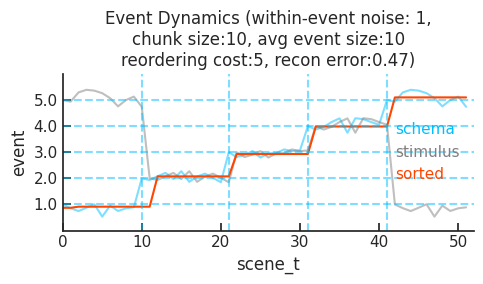

In [4]:
seed, n_events, n_dims, avg_event_len, sd_event_len = 0, 5, 1, 10, 1
between_event_drift,within_event_drift  = 5,1
chunk_size = [1,avg_event_len][1]

schema_event_ids, schema_event_templates, schema_event_lengths, schema_event_bounds, schema_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
    make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)
sorted_stream, insertion_count = sort(stim_stream, chunk_size=chunk_size); recon_err = np.median((np.array(sorted_stream)-schema_stream)**2)

plt.figure(figsize=(5,3)); plt.title(f"Event Dynamics (within-event noise: {within_event_drift},\nchunk size:{chunk_size}, avg event size:{avg_event_len}\nreordering cost:{insertion_count}, recon error:{recon_err:.2f})")
# plt.title(f"Event Dynamics (within-event drift: {within_event_drift})")
for stim_dim in range(schema_stream.shape[1]): plt.plot(schema_stream[:, stim_dim], alpha=.5,c='deepskyblue', label='schema')
for stim_dim in range(stim_stream.shape[1]): plt.plot(stim_stream[:, stim_dim], alpha=.5, c='gray', label='stimulus')
for stim_dim in range(len(sorted_stream[0])): plt.plot(np.array(sorted_stream)[:, stim_dim],   c='orangered', label='sorted')
# for bound in stim_event_bounds: plt.axvline(bound, ls="--", alpha=0.5, c='gray')
for bound in schema_event_bounds: plt.axvline(bound, ls="--", alpha=0.5, c='deepskyblue')
for hline in range(n_events): plt.axhline(hline*between_event_drift, ls="--", c='deepskyblue', alpha=0.5)
plt.xlabel("scene_t"); plt.ylabel("event"); plt.xlim(0,len(sorted_stream))
plt.yticks(np.linspace(0,between_event_drift*(n_events-1),between_event_drift), np.linspace(1,n_events,between_event_drift))
plt.ylim(-between_event_drift,between_event_drift*(n_events-1)+between_event_drift)
leg = plt.legend(frameon=False, handlelength=0, handletextpad=0)
for t in leg.get_texts(): t.set_color({'stimulus':'gray','schema':'deepskyblue','sorted':'orangered'}[t.get_text()])
plt.tight_layout(); plt.show()


Loop

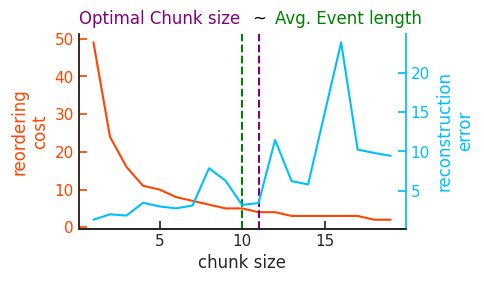

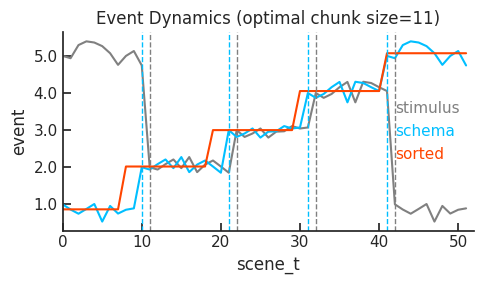

In [5]:
# generate stim
schema_event_ids, schema_event_templates, schema_event_lengths, schema_event_bounds, schema_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
    make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)

# sweep chunk sizes
chunk_sizes, insertion_counts, recon_errs, optimal_chunk_size = get_optimal_chunk_size(schema_stream, stim_stream, avg_event_len)

# plot sweep
fig, ax1 = plt.subplots(figsize=(5,3)); ax2 = ax1.twinx()
ax1.set(xlabel="chunk size", ylabel="reordering\ncost")
ax1.text(0,1.05,"Optimal Chunk size",transform=ax1.transAxes,color='purple')
ax1.text(.53,1.05,"~",transform=ax1.transAxes,color='black')
ax1.text(.6,1.05,"Avg. Event length",transform=ax1.transAxes,color='green')
ax2.set(ylabel="reconstruction\nerror")
ax1.plot(chunk_sizes,insertion_counts,c='orangered')
ax2.plot(chunk_sizes,recon_errs,c='deepskyblue')
ax1.axvline(optimal_chunk_size, ls="--", c='purple'); ax1.axvline(avg_event_len, ls="--", c='green')
ax1.spines['left'].set_color('orangered'); ax1.tick_params(axis='y', colors='orangered'); ax1.yaxis.label.set_color('orangered')
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color('deepskyblue'); ax2.tick_params(axis='y', colors='deepskyblue'); ax2.yaxis.label.set_color('deepskyblue')
plt.tight_layout(); plt.show()

# plot optimal chunk size result
sorted_stream, insertion_count = sort(stim_stream, chunk_size=optimal_chunk_size)
recon_err = np.median((np.array(sorted_stream)-schema_stream)**2)
plt.figure(figsize=(5,3)); plt.title(f"Event Dynamics (optimal chunk size={optimal_chunk_size})")
for stim_dim in range(stim_stream.shape[1]): plt.plot(stim_stream[:, stim_dim], c='gray',label='stimulus')
for stim_dim in range(schema_stream.shape[1]):   plt.plot(schema_stream[:, stim_dim],   c='deepskyblue', label='schema')
for stim_dim in range(schema_stream.shape[1]):   plt.plot(np.array(sorted_stream)[:, stim_dim],   c='orangered', label='sorted')
for bound in stim_event_bounds: plt.axvline(bound, ls="--", lw=1, c='gray')
for bound in schema_event_bounds: plt.axvline(bound, ls="--", lw=1, c='deepskyblue')
plt.xlabel("scene_t"); plt.ylabel("event"); plt.xlim(0,len(sorted_stream))
plt.yticks(np.linspace(0,between_event_drift*(n_events-1),between_event_drift), np.linspace(1,n_events,between_event_drift))

leg = plt.legend(frameon=False, handlelength=0, handletextpad=0)
for t in leg.get_texts(): t.set_color({'stimulus':'gray','schema':'deepskyblue','sorted':'orangered'}[t.get_text()])
plt.tight_layout(); plt.show()


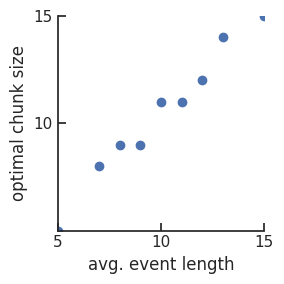

In [6]:
avg_event_lens = np.linspace(5,15,10).astype(int); optimal_chunk_sizes = []

fig, ax = plt.subplots(figsize=(3,3))
ax.set(xlabel="avg. event length",ylabel="optimal chunk size",xlim=(5,15),ylim=(5,15),xticks=np.linspace(5,15,3),yticks=np.linspace(5,15,3)[1:])
for avg_event_len in avg_event_lens:
    schema_event_ids, schema_event_templates, schema_event_lengths, schema_event_bounds, schema_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
        make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)
    *_, optimal_chunk_size = get_optimal_chunk_size(schema_stream, stim_stream, avg_event_len)
    optimal_chunk_sizes.append(optimal_chunk_size)
ax.scatter(avg_event_lens, optimal_chunk_sizes)
plt.tight_layout(); plt.show()


In [7]:
# seed, n_events, n_dims, avg_event_len, sd_event_len = 0, 5, 1, 10, 1
# between_event_drift,within_event_drift  = 5,5
# chunk_size = [1,avg_event_len][0]

# schema_event_ids, schema_event_templates, schema_event_lengths, schema_event_bounds, schema_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
#     make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)

# # per-scene labels: which original schema event each stim scene came from (so sorted points can keep their original color)
# stim_event_starts = np.concatenate(([0], stim_event_bounds)); stim_event_ends = np.concatenate((stim_event_bounds, [len(stim_stream)]))
# stim_event_labels = np.zeros(len(stim_stream), dtype=int)
# for i, eid in enumerate(stim_event_ids): stim_event_labels[stim_event_starts[i]:stim_event_ends[i]] = eid

# sorted_stream, sorted_labels, insertion_count = sort(stim_stream, chunk_size=chunk_size, labels=stim_event_labels); recon_err = np.median((np.array(sorted_stream)-schema_stream)**2)

# plt.figure(figsize=(5,3)); plt.title(f"Event Dynamics (within-event noise: {within_event_drift},\nchunk size:{chunk_size}, avg event size:{avg_event_len}\nreordering cost:{insertion_count}, recon error:{recon_err:.2f})")
# # plt.title(f"Event Dynamics (within-event drift: {within_event_drift})")
# # for stim_dim in range(schema_stream.shape[1]): plt.plot(schema_stream[:, stim_dim],   c='deepskyblue', label='schema')
# schema_colors = plt.cm.Blues(np.linspace(0.3, 0.9, n_events))  # light -> dark, one shade per event
# event_starts = np.concatenate(([0], schema_event_bounds)); event_ends = np.concatenate((schema_event_bounds, [len(schema_stream)]))
# for e in range(n_events):
#     for stim_dim in range(schema_stream.shape[1]):
#         plt.plot(np.arange(event_starts[e], event_ends[e]), schema_stream[event_starts[e]:event_ends[e], stim_dim], c=schema_colors[e], label='schema' if e==0 and stim_dim==0 else None)
# # for stim_dim in range(stim_stream.shape[1]): plt.plot(stim_stream[:, stim_dim], c='gray', alpha=0.5, label='stimulus')
# # for stim_dim in range(len(sorted_stream[0])): plt.plot(np.array(sorted_stream)[:, stim_dim],   c='orangered', label='sorted')
# sorted_colors = plt.cm.Oranges(np.linspace(0.3, 0.9, n_events))  # colored by *original* event id, not sorted position
# sorted_arr = np.array(sorted_stream)
# for stim_dim in range(sorted_arr.shape[1]):
#     seg_start = 0
#     for t in range(1, len(sorted_labels)+1):
#         if t == len(sorted_labels) or sorted_labels[t] != sorted_labels[seg_start]:
#             plt.plot(np.arange(seg_start, t), sorted_arr[seg_start:t, stim_dim], c=sorted_colors[sorted_labels[seg_start]], label='sorted' if seg_start==0 and stim_dim==0 else None)
#             seg_start = t
# # for bound in stim_event_bounds: plt.axvline(bound, ls="--", alpha=0.5, c='gray')
# for bound in schema_event_bounds: plt.axvline(bound, ls="--", alpha=0.5, c='deepskyblue')
# # for hline in range(n_events): plt.axhline(hline*between_event_drift, ls="--", c='deepskyblue', alpha=0.5)
# plt.xlabel("scene_t"); plt.ylabel("event"); plt.xlim(0,len(sorted_stream))
# plt.yticks(np.linspace(0,between_event_drift*(n_events-1),between_event_drift), np.linspace(1,n_events,between_event_drift))
# plt.ylim(-between_event_drift,between_event_drift*(n_events-1)+between_event_drift)
# leg = plt.legend(frameon=False, handlelength=0, handletextpad=0)
# for t in leg.get_texts(): t.set_color({'stimulus':'gray','schema':'deepskyblue','sorted':'orangered'}[t.get_text()])
# plt.tight_layout(); plt.show()
